In [2]:
import pandas as pd
df=pd.read_csv("/home/user/ml_datasets/loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,2199400.0,1416300.0,Salaried,21.0,Married,1.0,640.0,5.0,0.164,100800.0,167000.0,355000.0,48.0,Car,Rural,Not Graduate,Male,Private,Yes
1,2.0,109100.0,66100.0,Contract,51.0,Married,1.0,733.0,5.0,0.458,61300.0,279000.0,254000.0,48.0,Home,Urban,Graduate,Female,Unemployed,No
2,3.0,10500.0,6800.0,Unemployed,43.0,Married,4.0,474.0,1.0,0.384,3800.0,1612000.0,647000.0,60.0,Personal,Rural,Graduate,Male,Private,No
3,4.0,22400.0,11500.0,Self-employed,23.0,Married,2.0,533.0,2.0,0.603,4100.0,24200000.0,13600000.0,180.0,Education,Urban,Graduate,Female,Government,No
4,5.0,10000.0,6300.0,Salaried,45.0,Single,2.0,739.0,5.0,0.283,134700.0,3707000.0,1806000.0,60.0,Home,Semiurban,Not Graduate,Male,Unemployed,Yes


In [3]:
df.columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')

In [4]:
#target to predict : loan_approved
#prepare x & y (x: features, y: target)

#remove applicant id (it's just an identifier)
df=df.drop("Applicant_ID", axis=1)

In [5]:
#convert categorical variables into numeric
df=pd.get_dummies(df, drop_first=True)

In [12]:
df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Education_Level_Not Graduate', 'Gender_Male',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed',
       'Loan_Approved_Yes'],
      dtype='object')

In [13]:
y=df['Loan_Approved_Yes']
x=df.drop('Loan_Approved_Yes', axis=1)

In [16]:
#split data into train test
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=42)

In [18]:
#use logistic regression, since it is a binary classification problem
#Now train the model
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
#make predictions
y_pred=model.predict(x_test)

# 1= Loan approved
# 0 = Loan not approved

In [21]:
#check accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.74318


In [22]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[127146  13019]
 [ 38345  21490]]


In [32]:
#REPORT 
print("REPORT:\nCorrectly rejects many risky loans (127k cases)\nCorrectly approves some good applicants (21k cases)\nMakes two types of mistakes:\nApproving risky loans (13k)\nRejecting good applicants (38k)")

REPORT:
Correctly rejects many risky loans (127k cases)
Correctly approves some good applicants (21k cases)
Makes two types of mistakes:
Approving risky loans (13k)
Rejecting good applicants (38k)


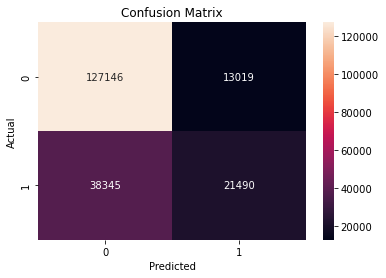

In [34]:
#Visualize the model
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot = True, fmt='d') #for colored grid, to print count in box & to print numbers as integers
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
print("A Logistic Regression model was trained to predict loan approval using applicant financial features. The model achieved 74.3% accuracy, demonstrating reasonable performance for a baseline credit scoring model.")

A Logistic Regression model was trained to predict loan approval using applicant financial features. The model achieved 74.3% accuracy, demonstrating reasonable performance for a baseline credit scoring model.
